# Example of the aitlas toolbox in the context of multi class image classification

## Import the required packages

In [ ]:
from aitlas.datasets import Optimal31Dataset
from aitlas.models import VisionTransformer
from aitlas.transforms import ResizeCenterCropFlipHVToTensor, ResizeCenterCropToTensor, ResizeRandomCropFlipHVToTensor
from aitlas.utils import image_loader

## Load the dataset

In [5]:
dataset_config = {
    "data_dir": "/home/dragik/data/Optimal31/",
    "csv_file": "/home/dragik/data/Optimal31/train.csv"
}
dataset = Optimal31Dataset(dataset_config)
print(f"Total number of patches: {len(dataset)}")

Total number of patches: 1116


## Show images from the dataset

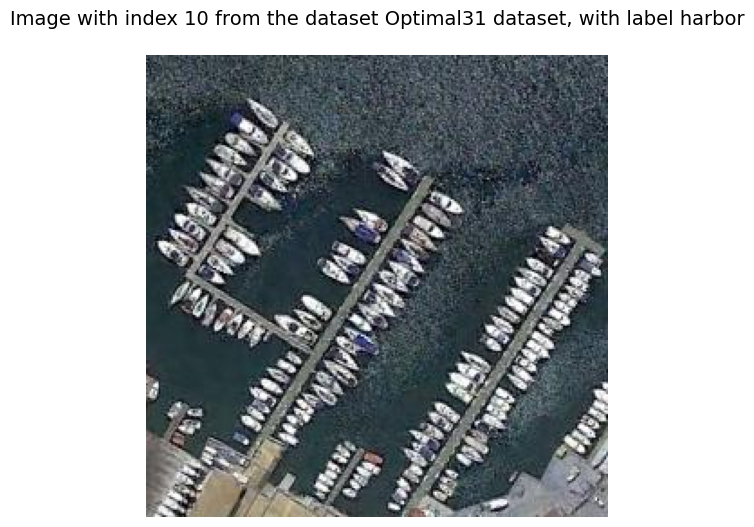

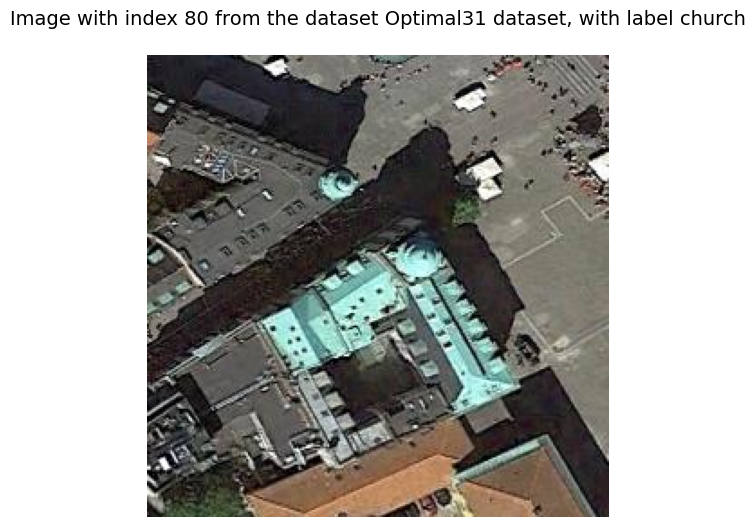

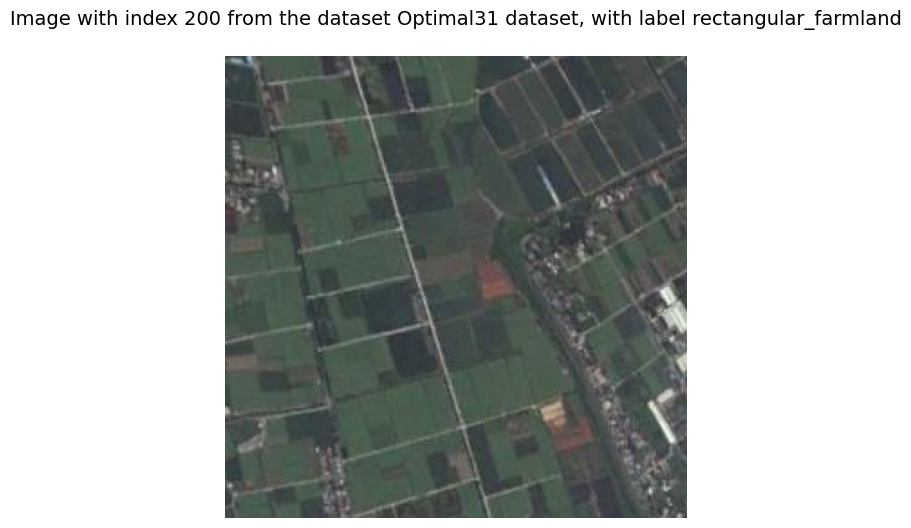

In [6]:
fig1 = dataset.show_image(10)
fig2 = dataset.show_image(80)
fig3 = dataset.show_image(200)

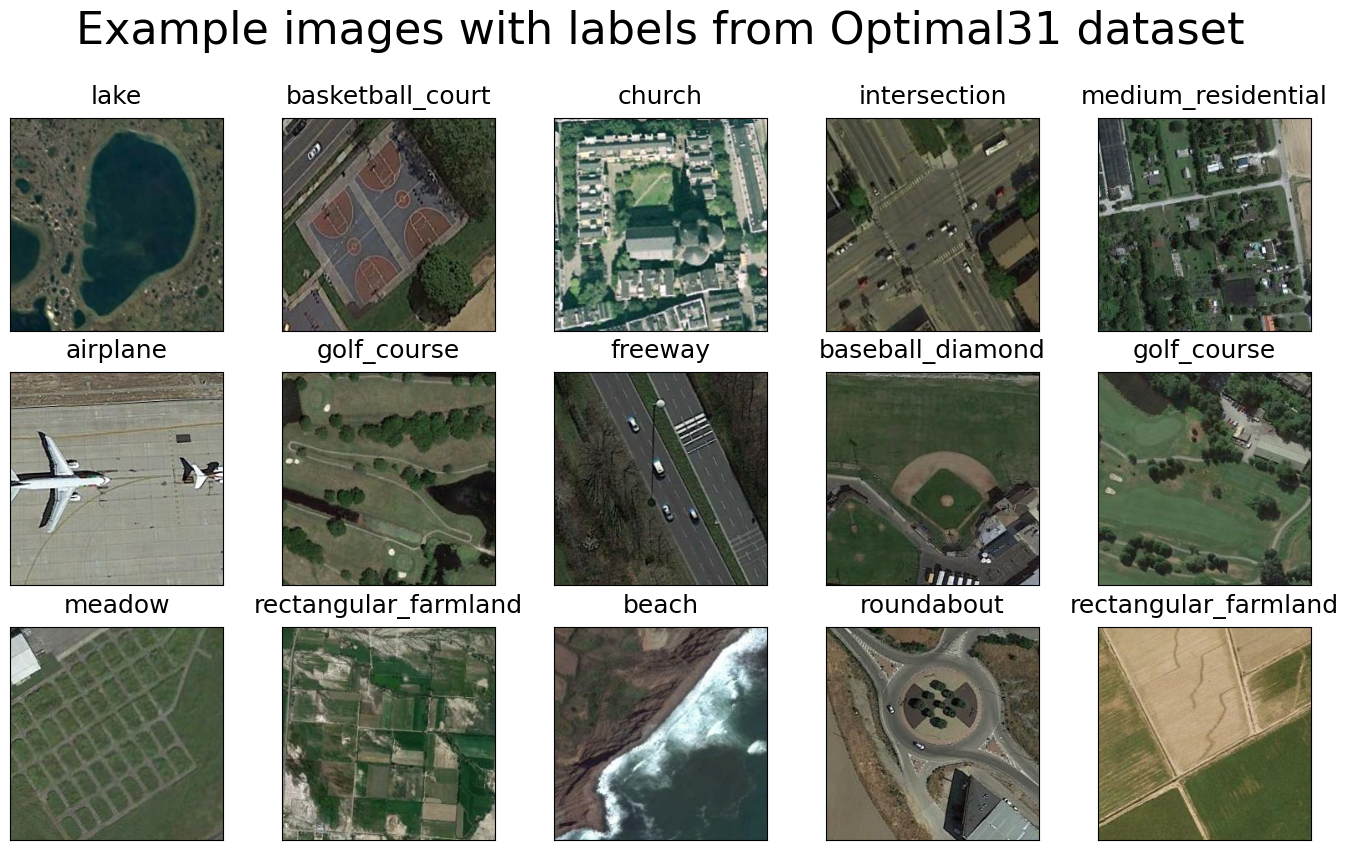

In [7]:
fig4 = dataset.show_batch(15)

## Inspect the data

In [8]:
dataset.data_distribution_table()

,Label,Count
0,airplane,36
1,airport,36
2,baseball_diamond,36
3,basketball_court,36
4,beach,36
5,bridge,36
6,chaparral,36
7,church,36
8,circular_farmland,36
9,commercial_area,36


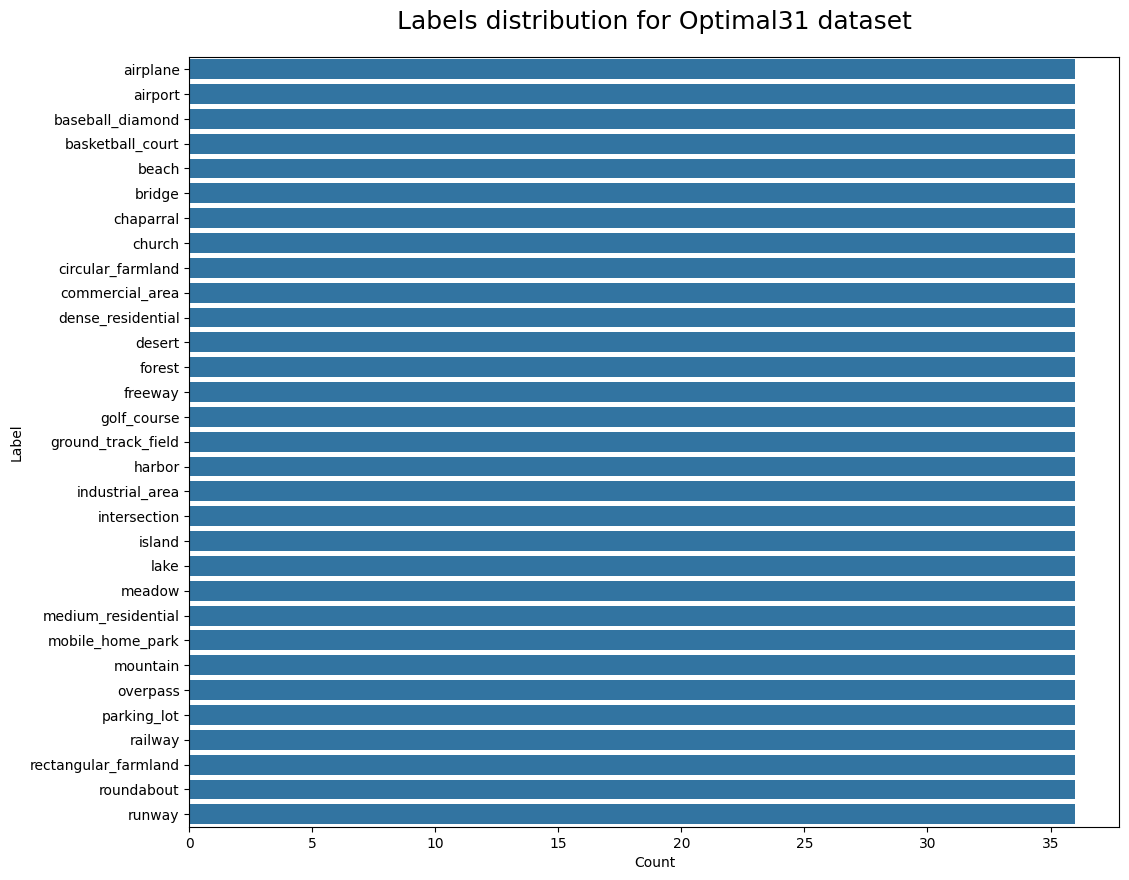

In [9]:
fig = dataset.data_distribution_barchart()

## Load train and validation splits

In [10]:
train_dataset_config = {
    "batch_size": 32,
    "shuffle": True,
    "num_workers": 4,
    "data_dir": "/home/dragik/data/Optimal31/",
    "csv_file": "/home/dragik/data/Optimal31/train.csv"
}

train_dataset = Optimal31Dataset(train_dataset_config)
train_dataset.transform = ResizeRandomCropFlipHVToTensor() 

validation_dataset_config = {
    "batch_size": 32,
    "shuffle": False,
    "num_workers": 4,
    "data_dir": "/home/dragik/data/Optimal31/",
    "csv_file": "/home/dragik/data/Optimal31/val.csv",
    "transforms": ["aitlas.transforms.ResizeCenterCropToTensor"]
}

validation_dataset = Optimal31Dataset(validation_dataset_config)
len(train_dataset), len(validation_dataset)

(1116, 372)

## Setup and create the model for training

In [11]:
epochs = 10
model_directory = "/home/dragik/data/experiments/optimal31/"
model_config = {
    "num_classes": 31, 
    "learning_rate": 0.0001,
    "pretrained": True,
    "metrics": ["accuracy", "precision", "recall", "f1_score"]
}
model = VisionTransformer(model_config)
model.prepare()

2025-11-11 10:50:29,099 INFO Loading pretrained weights from Hugging Face hub (timm/vit_base_patch16_224.augreg2_in21k_ft_in1k)
2025-11-11 10:50:29,623 INFO [timm/vit_base_patch16_224.augreg2_in21k_ft_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


## Train and validation

In [12]:
model.train_and_evaluate_model(
    train_dataset=train_dataset,
    epochs=epochs,
    model_directory=model_directory,
    val_dataset=validation_dataset,
    run_id='1',
)

2025-11-11 10:50:45,898 INFO Starting training.
training: 100%|██████████| 35/35 [00:21<00:00,  1.63it/s]
2025-11-11 10:51:07,681 INFO epoch: 1, time: 21, loss:  3.16713
testing on train set: 100%|██████████| 35/35 [00:07<00:00,  4.50it/s]
2025-11-11 10:51:17,570 INFO Accuracy:0.5555555555555556, Precision Micro:0.5555555555555556, Precision Macro:0.6084886216504264, Precision Weighted:0.6084886216504263, Precision per Class:[0.87096774 0.59259259 0.71428571 0.44776119 0.7027027  0.69565217
 0.825      0.38636364 0.82051282 0.39130435 0.5625     0.34020619
 0.86842105 0.43478261 0.8        0.5        0.46969697 0.48148148
 0.38709677 0.78571429 0.30769231 0.95454545 0.3373494  0.7
 0.66666667 0.61904762 1.         0.44230769 0.62264151 0.58823529
 0.54761905], Recall Micro:0.5555555555555556, Recall Macro:0.5555555555555556, Recall Weighted:0.5555555555555556, Recall per Class:[0.75       0.44444444 0.13888889 0.83333333 0.72222222 0.44444444
 0.91666667 0.47222222 0.88888889 0.5      

0.025870398341220766

## Predictions

2025-11-11 11:02:24,202 INFO Loading checkpoint /home/dragik/data/experiments/optimal31/checkpoint.pth.tar
2025-11-11 11:02:25,146 INFO Loaded checkpoint /home/dragik/data/experiments/optimal31/checkpoint.pth.tar at epoch 11


The amount of images for testing is 372


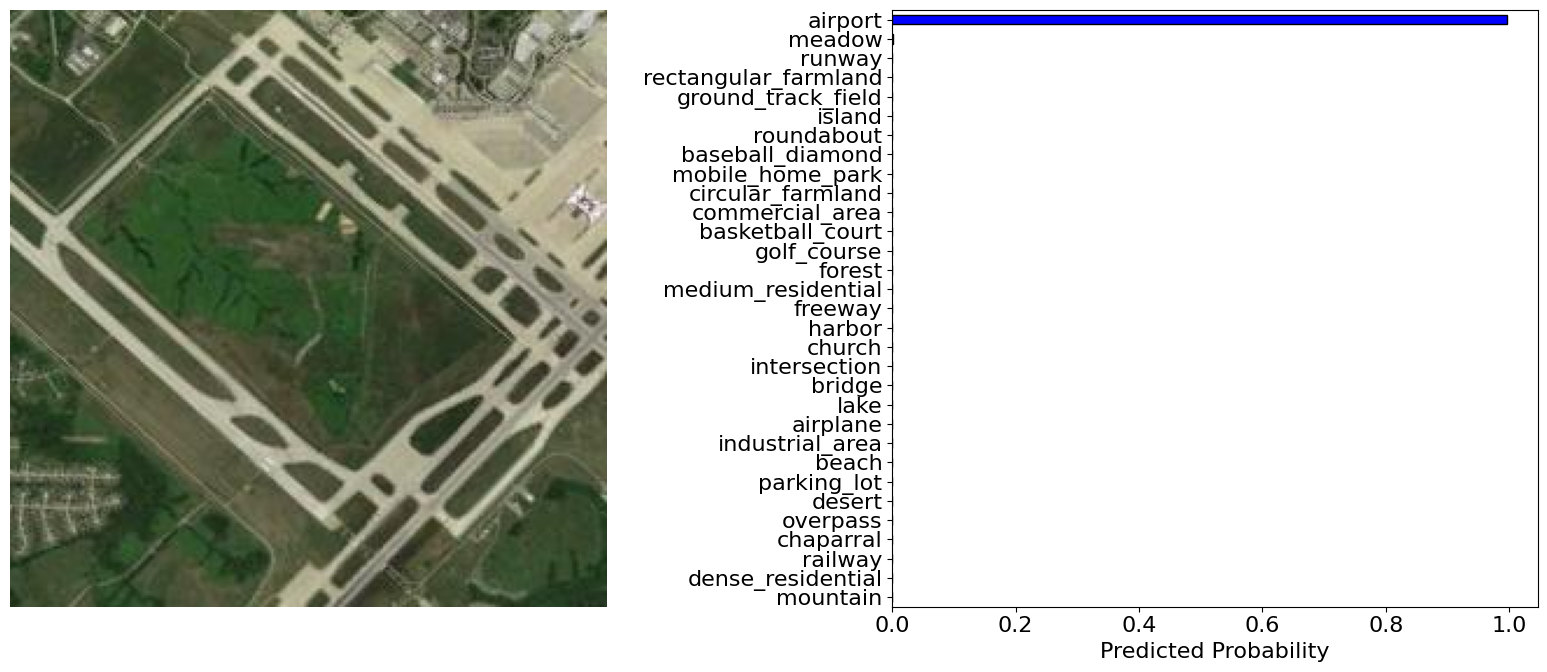

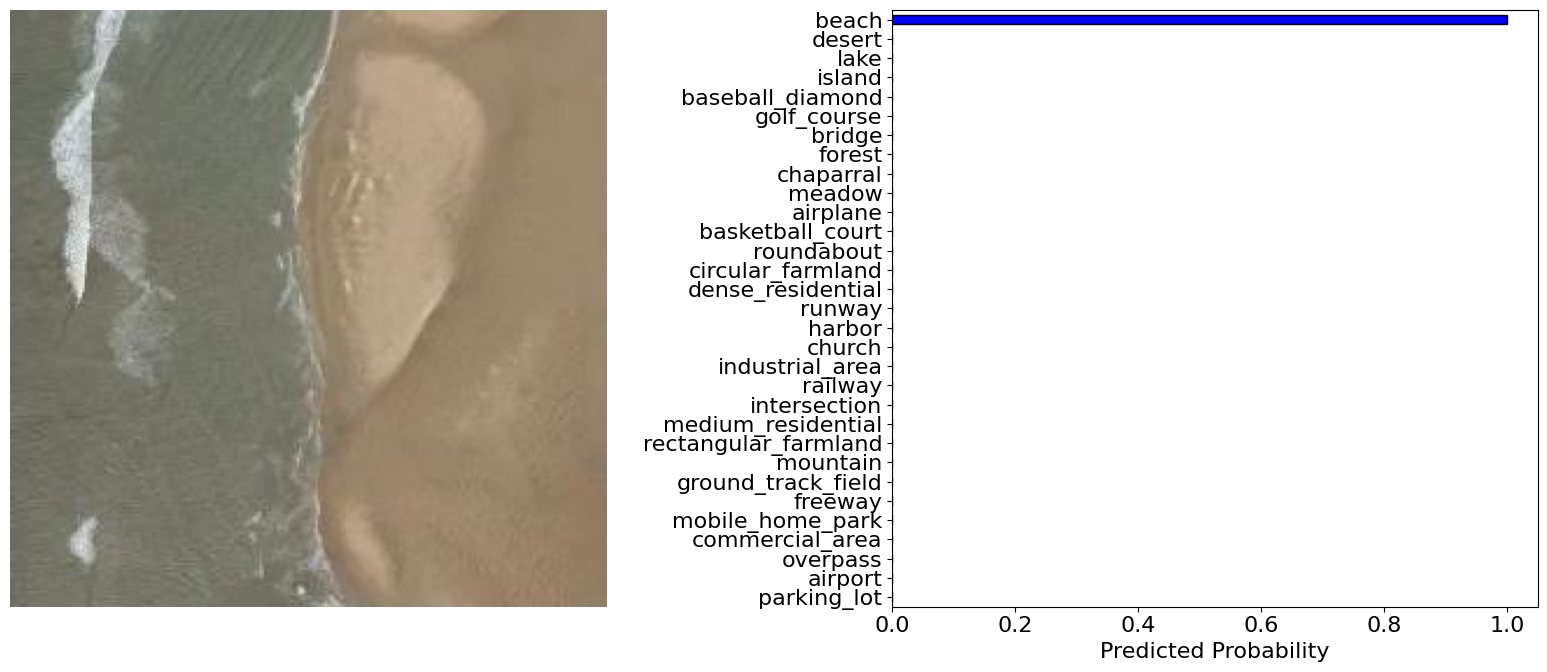

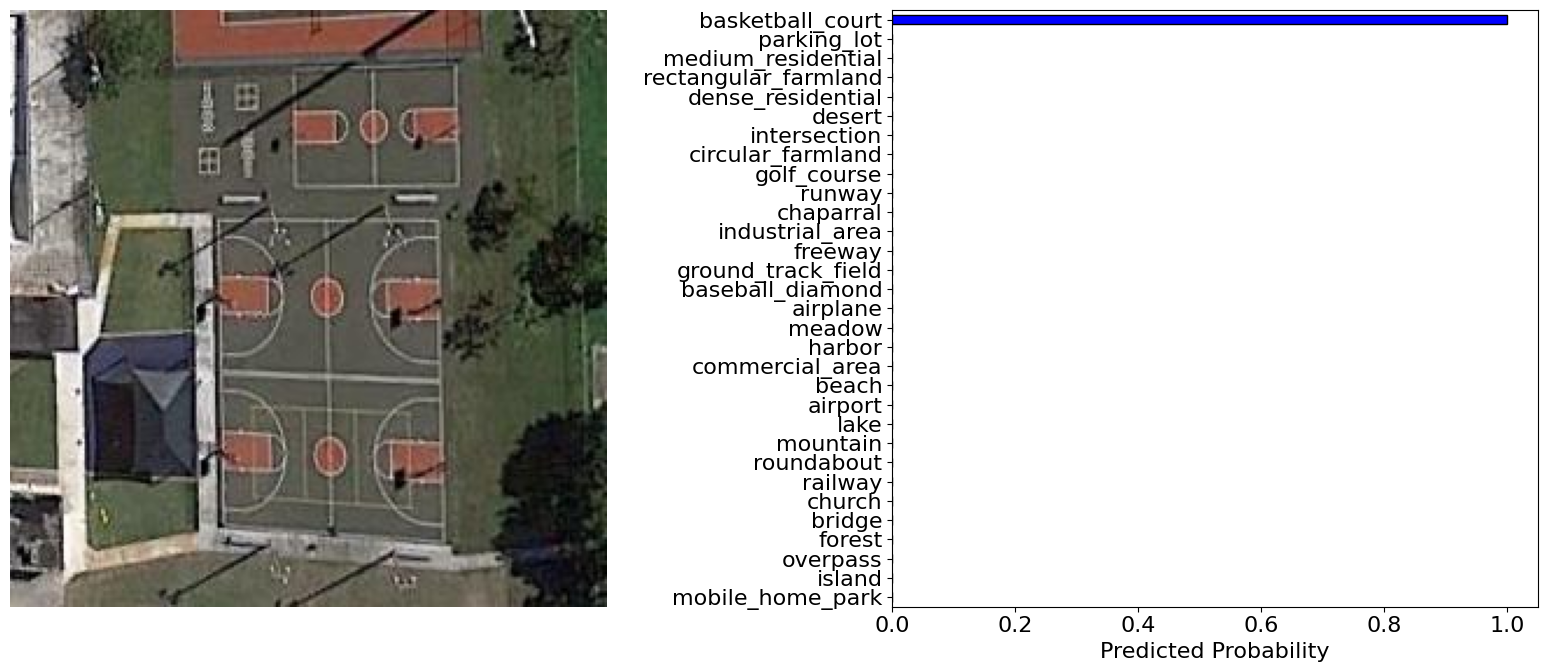

In [14]:
labels = ["airplane",
    "airport",
    "baseball_diamond",
    "basketball_court",
    "beach",
    "bridge",
    "chaparral",
    "church",
    "circular_farmland",
    "commercial_area",
    "dense_residential",
    "desert",
    "forest",
    "freeway",
    "golf_course",
    "ground_track_field",
    "harbor",
    "industrial_area",
    "intersection",
    "island",
    "lake",
    "meadow",
    "medium_residential",
    "mobile_home_park",
    "mountain",
    "overpass",
    "parking_lot",
    "railway",
    "rectangular_farmland",
    "roundabout",
    "runway"]
transform = ResizeCenterCropToTensor()

model_path = "/home/dragik/data/experiments/optimal31/checkpoint.pth.tar"
model.load_model(model_path)

test_dataset_config = {
    "data_dir": "/home/dragik/data/Optimal31/",
    "csv_file": "/home/dragik/data/Optimal31/test.csv",
}

test_dataset = Optimal31Dataset(test_dataset_config)
print(f'The amount of images for testing is {len(test_dataset)}')

image = test_dataset[0][0]
fig = model.predict_image(image, labels, transform)

image = test_dataset[10][0]
fig = model.predict_image(image, labels, transform)

image = test_dataset[100][0]
fig = model.predict_image(image, labels, transform)